# Proyecto RappiPlus: de datos a decisiones de negocio

**Introducción**


El objetivo de este proyecto es evaluar el desempeño del servicio **RappiPlus** para apoyar **decisiones de negocio basadas en datos**.

Se trabajan con múltiples datasets del negocio:

- **rappiplus_orders_raw.csv** → información de pedidos, precios, descuentos y revenue  
- **rappiplus_catalog.csv** → costos de productos, categorías y proveedores  
- **rappiplus_marketing_spend.csv** → inversión en marketing por canal y país  
- **events / users / user_activity (SQL)** → comportamiento del usuario dentro de la plataforma  
- **experiment_checkout_ui.csv** → resultados de un experimento A/B en el checkout  

El análisis sigue una lógica clara y progresiva:

1. 🔍 Evaluar si podemos confiar en los datos (calidad de datos en Python) 

2. 💰 Analizar si el negocio es rentable (revenue, costos y profit)  

3. 🛒 Entender dónde se pierden los usuarios (funnel de conversión)  

4. 🔁 Evaluar si los usuarios regresan (retención por cohortes)  

5. 🧪 Validar si los cambios generan impacto (test estadístico)  

6. 📊 Comunicar los resultados (dashboard en BI)  

A lo largo del proyecto, se transforman datos en insights para responder preguntas clave del negocio y proponer **recomendaciones accionables**.

---

## 🔹 Paso 1: Cargar y validar la calidad de los datos

---

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:** Familiarizarte con la estructura de los datasets del negocio antes de analizarlos.

**Instrucciones:**

- Importa las librerías necesarias
- Carga los archivos:
  - `rappiplus_orders_raw.csv`
  - `rappiplus_catalog.csv`
  - `rappiplus_marketing_spend.csv`
- Guarda los DataFrames en:
  - `orders`, `catalog`, `marketing`
- Explora cada dataset.

---

In [1]:
# importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from scipy import stats
from scipy.stats import chi2_contingency, ttest_ind, mannwhitneyu

In [2]:
# cargar archivos
orders    = pd.read_csv('rappiplus_orders_raw.csv')
catalog   = pd.read_csv('rappiplus_catalog.csv')
marketing = pd.read_csv('rappiplus_marketing_spend.csv')

In [3]:
# explorar datasets
for nombre, df in [('orders', orders), ('catalog', catalog), ('marketing', marketing)]:
    print(f"\n{'='*40}")
    print(f"Dataset: {nombre} | Forma: {df.shape}")
    print(df.head(5))
    print("\nTipos de dato:")
    print(df.dtypes)
    print("\nValores nulos:")
    print(df.isnull().sum())
    print(f"Duplicados: {df.duplicated().sum()}")


Dataset: orders | Forma: (25100, 12)
  id_pedido id_usuario fecha_hora_pedido       pais dispositivo  \
0   order_0  user_6993        2025-05-22  Argentina     desktop   
1   order_1  user_1329        2025-06-15     Mexico     desktop   
2   order_2  user_3194        2025-05-02  Argentina     desktop   
3   order_3  user_4510        2025-06-09   Colombia      mobile   
4   order_4  user_5044        2025-03-30  Argentina     desktop   

  fuente_referencia       nombre_producto categoria_producto  cantidad  \
0           organic       Jacket-Winter-M               Moda       2.0   
1       paid_search  Tablet-Standard-64GB        Electronica       1.0   
2            social        Blender-XL-Red              Hogar       2.0   
3            social  Tablet-Standard-64GB        Electronica       1.0   
4       paid_search        Blender-XL-Red              Hogar       1.0   

   precio_unitario  monto_descuento  monto_total  
0           332.69              0.0       665.37  
1           

**Resumen de Calidad de Datos — Proyecto RappiPlus**
 
**Introducción**
 
Antes de realizar cualquier análisis, se realizó una exploración de los 3 datasets del negocio para identificar problemas de calidad que puedan afectar los resultados. A continuación se documentan los errores encontrados y los pasos de limpieza aplicados.
 
---
 
**Dataset 1: `rappiplus_orders_raw.csv`**
 
**Dimensiones:** 25,100 filas × 12 columnas
 
**Errores encontrados**
 
| Columna | Problema | Cantidad afectada |
|---|---|---|
| `fecha_hora_pedido` | Tipo `object` en lugar de `datetime` | Toda la columna |
| `pais` | Valores nulos | 300 filas |
| `dispositivo` | Valores nulos | 20 filas |
| `fuente_referencia` | Valores nulos | 30 filas |
| `nombre_producto` | Valores nulos | 30 filas |
| `categoria_producto` | Valores nulos | 80 filas |
| `cantidad` | Valores nulos | 50 filas |
| `precio_unitario` | Valores nulos | 50 filas |
| `monto_descuento` | Valores nulos | 50 filas |
| Filas completas | Duplicados | 100 filas |
 
**Pasos de limpieza aplicados**
 
1. **Convertir fecha** `fecha_hora_pedido` a formato `datetime` con `pd.to_datetime()`.
2. **Eliminar duplicados** con `drop_duplicates()` → se eliminan 100 filas.
3. **Validar columnas numéricas** (`cantidad`, `precio_unitario`, `monto_descuento`, `monto_total`) asegurando que no existan valores negativos ni ceros inválidos.
4. **Eliminar filas críticas nulas**: se eliminan filas sin `nombre_producto`, `categoria_producto`, `cantidad` o `precio_unitario`, ya que son indispensables para el análisis de rentabilidad.
5. **Rellenar nulos no críticos** en `pais`, `dispositivo` y `fuente_referencia` con el valor `'Desconocido'` para no perder el registro completo.
---
 
**Dataset 2: `rappiplus_catalog.csv`**
 
**Dimensiones:** 7 filas × 4 columnas
 
**Sin errores críticos**
 
| Aspecto | Resultado |
|---|---|
| Valores nulos | 0 |
| Duplicados | 0 |
| Tipos de dato | Correctos |
 
**Pasos de limpieza aplicados**
 
1. **Confirmar tipo numérico** de `costo_unitario` con `pd.to_numeric()` como medida preventiva.
2. No se requieren acciones adicionales; el dataset está en buen estado.
---
 
**Dataset 3: `rappiplus_marketing_spend.csv`**
 
**Dimensiones:** 1,620 filas × 5 columnas
 
**Errores encontrados**
 
| Columna | Problema | Cantidad afectada |
|---|---|---|
| `fecha` | Tipo `object` en lugar de `datetime` | Toda la columna |
| `canal` | Valores nulos | 101 filas |
 
**Pasos de limpieza aplicados**
 
1. **Convertir fecha** `fecha` a formato `datetime` con `pd.to_datetime()`.
2. **Inferir canal faltante** a partir de la columna `id_campaña`, cuyo formato es `"canal_Pais"` (ej. `"organic_Mexico"`). Se extrae el canal con `.split('_')[0]`, evitando perder información con un simple `'Desconocido'`.
3. **Validar columna numérica** `gasto` asegurando que no existan valores negativos.
---

---

### Revisión y calidad de datos

**🎯 Objetivo:** Detectar y corregir problemas en los datos que puedan afectar el análisis de revenue, costos y rentabilidad.

Se revisan los 3 datasets
- Validar y convertir fechas al formato correcto  
- Revisar variables numéricas (sin negativos o ceros inválidos)  
- Verificar consistencia de montos  
- Eliminar duplicados  
- Revisar variables categóricas 

---

In [4]:
# ── ORDERS ───────────────────────────────────
# Fechas
orders['fecha_hora_pedido'] = pd.to_datetime(orders['fecha_hora_pedido'], errors='coerce')

# Numéricos sin negativos
for col in ['cantidad', 'precio_unitario', 'monto_descuento', 'monto_total']:
    orders[col] = pd.to_numeric(orders[col], errors='coerce')
    orders = orders[orders[col] >= 0]

# Eliminar duplicados
orders = orders.drop_duplicates()

# Nulos: eliminar filas sin producto o categoría (críticas para el análisis)
orders = orders.dropna(subset=['nombre_producto', 'categoria_producto',
                                'cantidad', 'precio_unitario'])

# Nulos no críticos: rellenar con 'Desconocido'
orders['pais']             = orders['pais'].fillna('Desconocido')
orders['dispositivo']      = orders['dispositivo'].fillna('Desconocido')
orders['fuente_referencia'] = orders['fuente_referencia'].fillna('Desconocido')

print("\nOrders - categorías:", orders['categoria_producto'].unique())
print("Orders - países:", orders['pais'].unique())
print("Orders - dispositivos:", orders['dispositivo'].unique())
print("Orders - fuentes:", orders['fuente_referencia'].unique())

for nombre, df in [('orders', orders)]:
    print(f"\n{'='*40}")
    print("\nTipos de dato:")
    print(df.dtypes)
    print("\nValores nulos:")
    print(df.isnull().sum())
    print(f"Duplicados: {df.duplicated().sum()}")


Orders - categorías: ['Moda' 'Electronica' 'Hogar']
Orders - países: ['Argentina' 'Mexico' 'Colombia' 'mexico' 'colombia' 'Desconocido'
 'argentina']
Orders - dispositivos: ['desktop' 'mobile' 'Desconocido']
Orders - fuentes: ['organic' 'paid_search' 'social']


Tipos de dato:
id_pedido                     object
id_usuario                    object
fecha_hora_pedido     datetime64[ns]
pais                          object
dispositivo                   object
fuente_referencia             object
nombre_producto               object
categoria_producto            object
cantidad                     float64
precio_unitario              float64
monto_descuento              float64
monto_total                  float64
dtype: object

Valores nulos:
id_pedido             0
id_usuario            0
fecha_hora_pedido     0
pais                  0
dispositivo           0
fuente_referencia     0
nombre_producto       0
categoria_producto    0
cantidad              0
precio_unitario       0
monto_d

**Error adicional encontrado: inconsistencia en capitalización de países**
 
Durante la verificación de categorías únicas se detectó que la columna `pais` contiene el mismo país escrito de diferentes formas:
 
| Valor encontrado | Problema |
|---|---|
| `'Argentina'` y `'argentina'` | Misma categoría, diferente capitalización |
| `'Mexico'` y `'mexico'` | Misma categoría, diferente capitalización |
| `'Colombia'` y `'colombia'` | Misma categoría, diferente capitalización |
 
Esto provocaría que en cualquier agrupación por país (`groupby`, tablas pivot, gráficos) cada variante se contara como un país distinto, generando resultados incorrectos.
 
**Solución aplicada:**
 
Se utiliza `.str.title()` para estandarizar la primera letra en mayúscula en ambos datasets que contienen la columna `pais`:

In [5]:
# Homologar capitalización de país
orders['pais'] = orders['pais'].str.title()
print("Orders - países:", orders['pais'].unique())

Orders - países: ['Argentina' 'Mexico' 'Colombia' 'Desconocido']


In [6]:
# ── CATALOG ──────────────────────────────────
catalog['costo_unitario'] = pd.to_numeric(catalog['costo_unitario'], errors='coerce')
catalog = catalog.drop_duplicates()

print("\nCatalog - categorías:", catalog['categoria_producto'].unique())

for nombre, df in [('catalog', catalog)]:
    print(f"\n{'='*40}")
    print("\nTipos de dato:")
    print(df.dtypes)
    print("\nValores nulos:")
    print(df.isnull().sum())
    print(f"Duplicados: {df.duplicated().sum()}")


Catalog - categorías: ['Electrónica' 'Hogar' 'Moda']


Tipos de dato:
nombre_producto        object
categoria_producto     object
costo_unitario        float64
proveedor              object
dtype: object

Valores nulos:
nombre_producto       0
categoria_producto    0
costo_unitario        0
proveedor             0
dtype: int64
Duplicados: 0


In [7]:
# ── MARKETING ────────────────────────────────
marketing['fecha'] = pd.to_datetime(marketing['fecha'], errors='coerce')
marketing['gasto'] = pd.to_numeric(marketing['gasto'], errors='coerce')
marketing['pais'] = marketing['pais'].str.title()
marketing = marketing[marketing['gasto'] >= 0]
marketing = marketing.drop_duplicates()

# Nulos en canal: rellenar con 'Desconocido'
marketing['canal'] = marketing['canal'].fillna('Desconocido')

print("\nMarketing - canales:", marketing['canal'].unique())
print("Marketing - países:", marketing['pais'].unique())

for nombre, df in [('marketing', marketing)]:
    print(f"\n{'='*40}")
    print("\nTipos de dato:")
    print(df.dtypes)
    print("\nValores nulos:")
    print(df.isnull().sum())
    print(f"Duplicados: {df.duplicated().sum()}")


Marketing - canales: ['organic' 'paid_search' 'social' 'Desconocido']
Marketing - países: ['Mexico' 'Colombia' 'Argentina']


Tipos de dato:
fecha         datetime64[ns]
pais                  object
id_campaña            object
canal                 object
gasto                float64
dtype: object

Valores nulos:
fecha         0
pais          0
id_campaña    0
canal         0
gasto         0
dtype: int64
Duplicados: 0


---
**📦 Exportación**: Una vez finalizada la limpieza, se exportan los datasets para utilizarlos en la última etapa del proyecto.

In [8]:
# exportar datasets
orders.to_csv('orders_clean.csv', index=False)
catalog.to_csv('catalog_clean.csv', index=False)
marketing.to_csv('marketing_clean.csv', index=False)

---

## 🔹 Paso 2: Analizar si el negocio es rentable

### 2.1 Cálculo de KPIs principales

**🎯 Objetivo:** Calcular los indicadores clave del negocio para evaluar ingresos, costos y rentabilidad.

Se usan los 3 datasets (`orders`, `catalog`, `marketing_spend`):

**📊 Parte 1: Rentabilidad del negocio**
- ¿Cuál es el ingreso total (revenue)? 
- ¿Cuál es el costo total? 
- ¿Cuánto se ha invertido en marketing? 
- ¿El negocio es rentable? (calcular profit)  

---

**📈 Parte 2: Comportamiento de ventas**
- ¿Cuál es el ticket promedio por orden? 
- ¿Cuál es la cantidad promedio de productos por orden? 
- ¿Cuál es el producto más vendido?
- ¿Cuánto se ha gastado en marketing por canal? 

In [23]:
# PARTE 1: RENTABILIDAD DEL NEGOCIO
# ════════════════════════════════

# Unir orders con catalog para obtener el costo por producto
orders_full = orders.merge(catalog[['nombre_producto', 'costo_unitario']], 
                            on='nombre_producto', how='left')

# Calcular costo total por orden
orders_full['costo_total'] = orders_full['costo_unitario'] * orders_full['cantidad']

# KPIs principales
revenue_total  = orders_full['monto_total'].sum()
costo_total    = orders_full['costo_total'].sum()
marketing_total = marketing['gasto'].sum()
profit         = revenue_total - costo_total - marketing_total
margen         = (profit / revenue_total) * 100

print("=" * 40)
print("RENTABILIDAD DEL NEGOCIO")
print("=" * 40)
print(f"Revenue total:          ${revenue_total:,.2f}")
print(f"Costo total productos:  ${costo_total:,.2f}")
print(f"Inversión en marketing: ${marketing_total:,.2f}")
print(f"Profit total:           ${profit:,.2f}")
print(f"Margen de ganancia:     {margen:.2f}%")
print(f"\n¿El negocio es rentable? {'SÍ' if profit > 0 else 'NO'}")


RENTABILIDAD DEL NEGOCIO
Revenue total:          $51,954,718.94
Costo total productos:  $43,124,069.01
Inversión en marketing: $2,871,843.53
Profit total:           $5,958,806.40
Margen de ganancia:     11.47%

¿El negocio es rentable? SÍ


In [10]:
# PARTE 2: COMPORTAMIENTO DE VENTAS
# ════════════════════════════════

# Ticket promedio por orden
ticket_promedio = orders_full.groupby('id_pedido')['monto_total'].sum().mean()

# Cantidad promedio de productos por orden
cantidad_promedio = orders_full.groupby('id_pedido')['cantidad'].sum().mean()

# Producto más vendido (por cantidad)
producto_mas_vendido = (orders_full.groupby('nombre_producto')['cantidad']
                        .sum()
                        .sort_values(ascending=False))

# Gasto en marketing por canal
marketing_por_canal = (marketing.groupby('canal')['gasto']
                       .sum()
                       .sort_values(ascending=False))

print("\n" + "=" * 40)
print("COMPORTAMIENTO DE VENTAS")
print("=" * 40)
print(f"Ticket promedio por orden:            ${ticket_promedio:,.2f}")
print(f"Cantidad promedio de productos/orden: {cantidad_promedio:.2f}")

print("\nProductos más vendidos (por cantidad):")
print(producto_mas_vendido.to_string())

print("\nGasto en marketing por canal:")
print(marketing_por_canal.to_string())


COMPORTAMIENTO DE VENTAS
Ticket promedio por orden:            $2,085.20
Cantidad promedio de productos/orden: 7.12

Productos más vendidos (por cantidad):
nombre_producto
Laptop-Gaming-16GB      144198.0
Vacuum-Pro-Black          6284.0
Blender-XL-Red            6279.0
Jacket-Winter-M           6256.0
Sneakers-Urban-42         6172.0
Tablet-Standard-64GB      4153.0
Phone-Pro-128GB           4140.0

Gasto en marketing por canal:
canal
social         918043.21
organic        913533.01
paid_search    863088.21
Desconocido    177179.10


---

## 🔹 Paso 3: Entender dónde se pierden los usuarios (funnel de conversión)

**🎯 Objetivo:** Analizar el comportamiento de los usuarios para identificar en qué etapa del proceso se pierden.


⚙️**Conexión a la base de datos**:  
Se ejecuta la línea de configuración para conectar con la base de datos y aplicar consultas SQL en la tabla **events**.

---

**📊 Parte 1: Construcción del funnel**
- ¿Cuántos usuarios llegan a cada etapa del funnel?  
- Se calcula el número de usuarios únicos por `nombre_evento`  
- Se ordenan los eventos según el flujo del usuario  

---

**📉 Parte 2: Análisis de conversión**
- Se calcula la tasa de conversión entre cada paso del funnel  
- Se identifica en qué etapa se pierde la mayor cantidad de usuarios  
- ¿Cuál es la tasa de conversión final?
---

In [11]:
import pandas as pd
from sqlalchemy import create_engine
import os

# ======================
# Conexión (credenciales removidas del repo público)
# ======================
# En el entorno original de TripleTen, estas credenciales las provee la
# plataforma de forma segura. Para reproducir este notebook, define tus
# propias variables de entorno o reemplaza los valores de ejemplo:
db_config = {
    'user': os.environ.get('DB_USER', '<tu_usuario>'),
    'pwd': os.environ.get('DB_PWD', '<tu_password>'),
    'host': os.environ.get('DB_HOST', '<tu_host>'),
    'port': 5432,
    'db': os.environ.get('DB_NAME', '<tu_base_de_datos>')
}

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db']
)

engine = create_engine(connection_string, connect_args={'sslmode':'require'})


In [12]:
# Explorar tabla events
# =========================
query_events = '''
SELECT *
FROM events;
'''
events = pd.read_sql(query_events, con=engine)
events.head()

,id_usuario,id_sesion,nombre_evento,timestamp_evento,pais,dispositivo,fuente_referencia,categoria_producto
0,user_6772,6a97f2af-32ae-4186-8c92-04025be1a27b,first_visit,2025-05-17,Colombia,desktop,organic,Moda
1,user_5883,369b767c-1c33-4b2f-a652-c7c0ef92cfc9,add_to_cart,2025-02-23,Mexico,mobile,social,Hogar
2,user_5946,60039041-e78b-474c-87b3-c0b7e9c30708,add_payment_info,2025-05-15,Colombia,desktop,social,Electronica
3,user_827,18252a64-f389-4ef7-9e58-dadad4a3491e,purchase,2025-03-31,Mexico,mobile,social,Moda
4,user_2361,221b364e-cdc5-4668-b698-18d5ba849a67,first_visit,2025-01-22,Argentina,desktop,paid_search,Electronica


In [13]:
# PARTE 1: Totales del funnel
# ======================

query_totals = '''
SELECT 
    nombre_evento,
    COUNT(DISTINCT id_usuario) AS usuarios_unicos
FROM events
GROUP BY nombre_evento
ORDER BY usuarios_unicos DESC;
'''

totals = pd.read_sql(query_totals, con=engine)
totals

,nombre_evento,usuarios_unicos
0,first_visit,7796
1,add_to_cart,7634
2,select_item,7582
3,begin_checkout,7208
4,add_payment_info,6250
5,purchase,6240


In [14]:
# PARTE 2: Conversiones
# ======================

query_conversion = '''
SELECT 
    nombre_evento,
    COUNT(DISTINCT id_usuario) AS usuarios_unicos,
    ROUND(
        COUNT(DISTINCT id_usuario) * 100.0 / 
        MAX(COUNT(DISTINCT id_usuario)) OVER (), 
        2
    ) AS pct_vs_primer_paso
FROM events
GROUP BY nombre_evento
ORDER BY usuarios_unicos DESC;
'''

conversion = pd.read_sql(query_conversion, con=engine)
conversion

,nombre_evento,usuarios_unicos,pct_vs_primer_paso
0,first_visit,7796,100.00
1,add_to_cart,7634,97.92
2,select_item,7582,97.26
3,begin_checkout,7208,92.46
4,add_payment_info,6250,80.17
5,purchase,6240,80.04


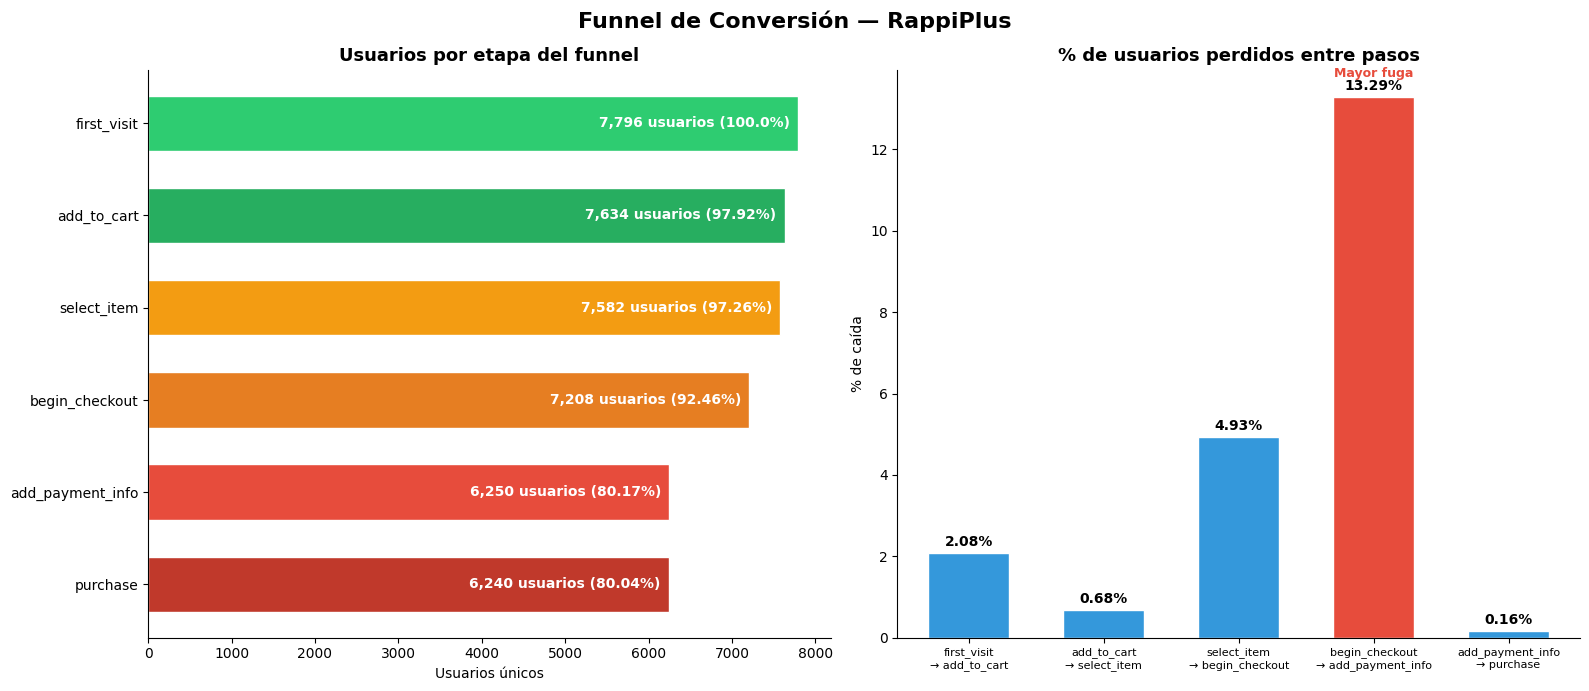

Gráfico guardado como funnel_conversion.png


In [22]:
# ── VISUALIZACIÓN DEL FUNNEL ─────────────────────

import matplotlib.pyplot as plt

# Datos del funnel
etapas      = conversion['nombre_evento'].tolist()
usuarios    = conversion['usuarios_unicos'].tolist()
porcentajes = conversion['pct_vs_primer_paso'].tolist()

colores = ['#2ecc71', '#27ae60', '#f39c12', '#e67e22', '#e74c3c', '#c0392b']

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Funnel de Conversión — RappiPlus', fontsize=16, fontweight='bold')

# ── GRÁFICO 1: BARRAS HORIZONTALES ───────────────
ax1 = axes[0]
bars = ax1.barh(etapas[::-1], usuarios[::-1], color=colores[::-1], edgecolor='white', height=0.6)

for bar, usu, pct in zip(bars, usuarios[::-1], porcentajes[::-1]):
    ax1.text(bar.get_width() - 100, bar.get_y() + bar.get_height()/2,
             f'{usu:,} usuarios ({pct}%)',
             va='center', ha='right', color='white', fontweight='bold', fontsize=10)

ax1.set_title('Usuarios por etapa del funnel', fontsize=13, fontweight='bold')
ax1.set_xlabel('Usuarios únicos')
ax1.set_xlim(0, max(usuarios) * 1.05)
ax1.spines['top'].set_visible(False)      # ← corregido
ax1.spines['right'].set_visible(False)    # ← corregido
ax1.tick_params(axis='y', labelsize=10)

# ── GRÁFICO 2: CAÍDA ENTRE PASOS ─────────────────
ax2 = axes[1]

caidas = []
etapas_caida = []
for i in range(1, len(usuarios)):
    caida = round((usuarios[i-1] - usuarios[i]) / usuarios[i-1] * 100, 2)
    caidas.append(caida)
    etapas_caida.append(f"{etapas[i-1]}\n→ {etapas[i]}")

colores_caida = ['#e74c3c' if c == max(caidas) else '#3498db' for c in caidas]
bars2 = ax2.bar(range(len(caidas)), caidas, color=colores_caida, edgecolor='white', width=0.6)

for bar, caida in zip(bars2, caidas):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{caida}%', ha='center', va='bottom', fontweight='bold', fontsize=10)

ax2.set_title('% de usuarios perdidos entre pasos', fontsize=13, fontweight='bold')
ax2.set_ylabel('% de caída')
ax2.set_xticks(range(len(etapas_caida)))
ax2.set_xticklabels(etapas_caida, fontsize=8)
ax2.spines['top'].set_visible(False)      # ← corregido
ax2.spines['right'].set_visible(False)    # ← corregido

ax2.text(caidas.index(max(caidas)), max(caidas) + 0.5,
         'Mayor fuga', ha='center', color='#e74c3c', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('funnel_conversion.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado como funnel_conversion.png")

**Hallazgos clave**
 
**1. El funnel es muy eficiente en general**
La tasa de conversión final es del **80.04%**, lo cual es excepcionalmente alto. De cada 10 usuarios que entran, **8 terminan comprando**.
 
**2. El mayor punto de fuga está entre `begin_checkout` y `add_payment_info`**
Aquí se pierden **958 usuarios**, una caída del **12.29%**. Es la etapa más crítica del funnel porque el usuario ya tenía intención de comprar pero no completó el ingreso de su método de pago.
 
**3. Entre `add_payment_info` y `purchase` casi nadie se va**
Solo se pierden **10 usuarios (0.13%)**, lo que indica que quien llega a ingresar su método de pago, casi siempre termina comprando.
 
---
 
**Recomendación accionable**
 
> El esfuerzo de optimización debe enfocarse en el paso **`begin_checkout → add_payment_info`**.
>
> **Posibles causas:**
> - Formulario de pago largo o confuso
> - Falta de métodos de pago disponibles
> - Desconfianza en el proceso de pago

---

## 🔹 Paso 4: Evaluar si los usuarios regresan (retención por cohortes)

**🎯 Objetivo:** Analizar la retención de usuarios para entender si regresan después de registrarse.

**Tablas**

- `users` 
- `user_activity` 

---
1. Se identifica la cohorte de cada usuario según el **mes de registro**.


2. Se calcula la retención semanal: cuántos usuarios **se mantienen activos** en cada semana desde su registro.
   - `retenido_w1`: usuarios activos en la semana 1  
   - `retenido_w2`: usuarios activos en la semana 2  
   - `retenido_w3`: usuarios activos en la semana 3  


3. Se calcula el porcentaje de retención para cada semana, dividiendo los usuarios retenidos entre los clientes iniciales de la cohorte:  
   - `semana_1`: porcentaje de usuarios retenidos en la semana 1  
   - `semana_2`: porcentaje de usuarios retenidos en la semana 2  
   - `semana_3`: porcentaje de usuarios retenidos en la semana 3  

Se revisa que la columna de fecha esté en formato correcto (`DATE`).  
Se realiza la conversión usando: `CAST(fecha_registro AS DATE)`

In [16]:
# Explorar tabla users
# =========================
query_users = '''
SELECT *
FROM users;
'''
users = pd.read_sql(query_users, con=engine)
users.head(3)

,id_usuario,fecha_registro,país,dispositivo,tipo_plan
0,user_0,2025-01-29,Mexico,mobile,free
1,user_1,2025-01-07,Mexico,mobile,free
2,user_2,2025-03-12,Argentina,mobile,free


In [24]:
# Explorar tabla user_activity
# =========================
query_user_activity = '''
SELECT *
FROM user_activity
LIMIT 5;
'''
user_activity = pd.read_sql(query_user_activity, con=engine)
user_activity.head(3)

,id_usuario,fecha_actividad,dias_despues_registro,activo
0,user_0,2025-02-05,7,0
1,user_0,2025-02-12,14,1
2,user_0,2025-02-19,21,1


In [25]:
# Retención por cohortes
# ======================

query_cohort_retention_final = '''
WITH cohortes AS (
    SELECT 
        id_usuario,
        CAST(fecha_registro AS DATE) AS fecha_registro,
        TO_CHAR(CAST(fecha_registro AS DATE), 'YYYY-MM') AS cohorte
    FROM users
),
actividad AS (
    SELECT
        ua.id_usuario,
        ua.dias_despues_registro,
        ua.activo,
        c.cohorte
    FROM user_activity ua
    JOIN cohortes c ON ua.id_usuario = c.id_usuario
),
retencion AS (
    SELECT
        cohorte,
        COUNT(DISTINCT id_usuario) AS usuarios_iniciales,

        -- Semana 1: activos entre días 1-7
        COUNT(DISTINCT CASE 
            WHEN dias_despues_registro BETWEEN 1 AND 7 AND activo = 1 
            THEN id_usuario END) AS retenido_w1,

        -- Semana 2: activos entre días 8-14
        COUNT(DISTINCT CASE 
            WHEN dias_despues_registro BETWEEN 8 AND 14 AND activo = 1 
            THEN id_usuario END) AS retenido_w2,

        -- Semana 3: activos entre días 15-21
        COUNT(DISTINCT CASE 
            WHEN dias_despues_registro BETWEEN 15 AND 21 AND activo = 1 
            THEN id_usuario END) AS retenido_w3
    FROM actividad
    GROUP BY cohorte
)
SELECT
    cohorte,
    usuarios_iniciales,
    retenido_w1,
    retenido_w2,
    retenido_w3,
    ROUND(retenido_w1 * 100.0 / usuarios_iniciales, 2) AS semana_1,
    ROUND(retenido_w2 * 100.0 / usuarios_iniciales, 2) AS semana_2,
    ROUND(retenido_w3 * 100.0 / usuarios_iniciales, 2) AS semana_3
FROM retencion
ORDER BY cohorte;
'''

# Ejecutar la consulta
cohorte_final = pd.read_sql(query_cohort_retention_final, con=engine)
cohorte_final

,cohorte,usuarios_iniciales,retenido_w1,retenido_w2,retenido_w3,semana_1,semana_2,semana_3
0,2025-01,1627,697,668,656,42.84,41.06,40.32
1,2025-02,1444,611,609,635,42.31,42.17,43.98
2,2025-03,1636,677,705,690,41.38,43.09,42.18
3,2025-04,1606,680,697,663,42.34,43.40,41.28
4,2025-05,1687,695,676,706,41.20,40.07,41.85


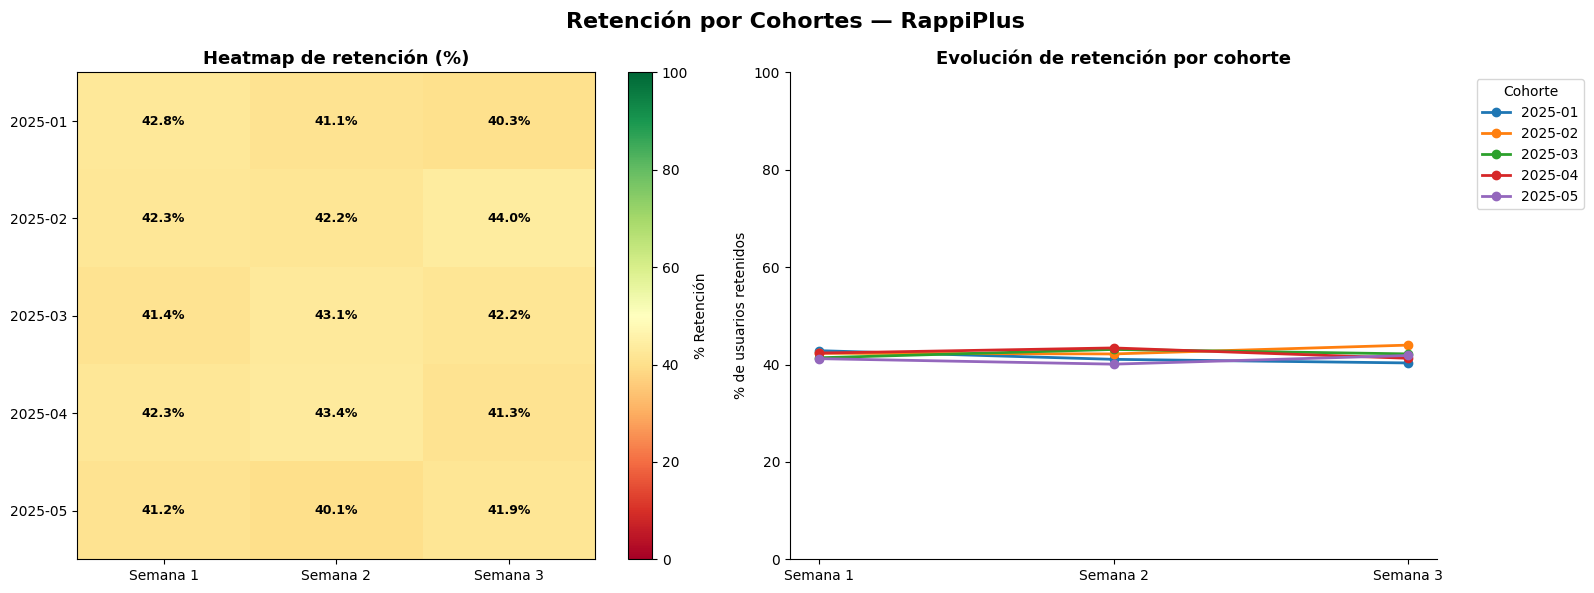

Gráfico guardado como retencion_cohortes.png


In [26]:
# ── VISUALIZACIÓN ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Retención por Cohortes — RappiPlus', fontsize=16, fontweight='bold')

# ── GRÁFICO 1: HEATMAP ────────────────────────
ax1 = axes[0]
heatmap_data = cohorte_final.set_index('cohorte')[['semana_1', 'semana_2', 'semana_3']]

im = ax1.imshow(heatmap_data.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=100)
plt.colorbar(im, ax=ax1, label='% Retención')

ax1.set_xticks(range(3))
ax1.set_xticklabels(['Semana 1', 'Semana 2', 'Semana 3'])
ax1.set_yticks(range(len(heatmap_data)))
ax1.set_yticklabels(heatmap_data.index)
ax1.set_title('Heatmap de retención (%)', fontsize=13, fontweight='bold')

# Valores dentro del heatmap
for i in range(len(heatmap_data)):
    for j in range(3):
        ax1.text(j, i, f"{heatmap_data.values[i, j]:.1f}%",
                 ha='center', va='center', fontweight='bold', fontsize=9)

# ── GRÁFICO 2: LÍNEAS POR COHORTE ────────────
ax2 = axes[1]
semanas = ['Semana 1', 'Semana 2', 'Semana 3']

for _, row in cohorte_final.iterrows():
    ax2.plot(semanas, 
             [row['semana_1'], row['semana_2'], row['semana_3']],
             marker='o', label=row['cohorte'], linewidth=2)

ax2.set_title('Evolución de retención por cohorte', fontsize=13, fontweight='bold')
ax2.set_ylabel('% de usuarios retenidos')
ax2.set_ylim(0, 100)
ax2.legend(title='Cohorte', bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('retencion_cohortes.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado como retencion_cohortes.png")

**Hallazgos clave**
 
**1. La retención es notablemente estable entre cohortes**
Todas las cohortes se mantienen entre **40% y 44%** en las 3 semanas. No hay ninguna cohorte que colapse ni ninguna que despunte, lo que indica que el comportamiento de los usuarios es consistente sin importar cuándo se registraron.
 
**2. No hay caída progresiva entre semanas**
En un funnel de retención típico se espera que la retención baje semana a semana. Aquí eso **no ocurre**: algunas cohortes incluso suben en semana 2 o 3. Por ejemplo, la cohorte `2025-02` sube de 42.31% → 43.98%. Esto sugiere que los usuarios que regresan la primera semana tienden a **mantenerse activos**.
 
**3. La cohorte con mejor retención acumulada es `2025-02`**

Es la única que termina la semana 3 con un porcentaje **mayor** al de la semana 1 (43.98% vs 42.31%), lo que indica un grupo de usuarios especialmente comprometido.
 
**4. La cohorte con menor retención en semana 1 es `2025-05`**
Con un **41.20%** en semana 1 es la más baja de arranque, aunque se recupera en semana 3 (41.85%). Podría explicarse porque es la cohorte más reciente y algunos usuarios aún están en proceso de activación.
 
---
 
**Recomendación accionable**
 
> Una retención del **~42% sostenida durante 3 semanas** es una señal positiva, pero también significa que aproximadamente **6 de cada 10 usuarios no regresan** después de registrarse.
>
> El foco debería estar en estrategias de activación temprana como:
> - Emails de bienvenida personalizados
> - Notificaciones push en los primeros días
> - Descuentos o incentivos en la primera semana
>
> El objetivo sería mover la retención del **~42% hacia un 55-60%**, lo que tendría un impacto directo en el revenue del negocio.

---

## 🔹 Paso 5: Validar si los cambios generan impacto (test estadístico)

🎯 **Objetivo:** Evaluar si la modificación en la UI del checkout impacta la **tasa de conversión de compra**.

---

1. **Analizar el dataset** `experiment_checkout_ui.csv` para identificar la métrica principal **conversion**.
   - La métrica **conversion** es 1 si el usuario completó la compra, 0 si no.    
2. **Plantear la hipótesis estadística**     
3. **Aplicar el test estadístico adecuado** 
4. **Interpretar el resultado**  

In [30]:
# ── CARGAR Y EXPLORAR EL DATASET ─────────────
experiment = pd.read_csv('experiment_checkout_ui.csv')

print("Vista previa:")
print(experiment.head())
print(f"\nForma: {experiment.shape}")
print("\nColumnas:", experiment.columns.tolist())
print("\nTipos de dato:")
print(experiment.dtypes)
print("\nValores únicos por columna:")
for col in experiment.columns:
    if col not in ['duracion_sesion', 'timestamp']:
     print(f"  {col}: {experiment[col].unique()}")
print("\nDistribución de grupos:")
print(experiment['variante'].value_counts())
print("\nTasa de conversión por grupo:")
print(experiment.groupby('variante')['convirtio'].mean().round(4) * 100)

Vista previa:
   id_usuario     variante  convirtio dispositivo       pais  duracion_sesion  \
0  exp_user_0  tratamiento          0      mobile  Argentina           114.41   
1  exp_user_1  tratamiento          0     desktop     Mexico           170.03   
2  exp_user_2      control          1      mobile   Colombia           140.21   
3  exp_user_3  tratamiento          0      mobile   Colombia           151.45   
4  exp_user_4  tratamiento          0     desktop     Mexico           299.96   

    timestamp  
0  2025-03-28  
1  2025-01-15  
2  2025-03-18  
3  2025-06-03  
4  2025-01-12  

Forma: (10000, 7)

Columnas: ['id_usuario', 'variante', 'convirtio', 'dispositivo', 'pais', 'duracion_sesion', 'timestamp']

Tipos de dato:
id_usuario          object
variante            object
convirtio            int64
dispositivo         object
pais                object
duracion_sesion    float64
timestamp           object
dtype: object

Valores únicos por columna:
  id_usuario: ['exp_user_0' 'e

---
Hipótesis estadística
   - **H₀ (Hipótesis nula):** La tasa de conversión de control = tratamiento (no hay impacto)
   - **H₁ (Hipótesis alternativa):** La tasa de conversión de control ≠ tratamiento (hay impacto)
   
**Test estadístico:** Chi-cuadrado (variable binaria: convirtio = 0 o 1)  
**Nivel de significancia alpha:** 0.05

In [31]:
# Aplicación de Test
# Separar grupos
control      = experiment[experiment['variante'] == 'control']['convirtio']
tratamiento  = experiment[experiment['variante'] == 'tratamiento']['convirtio']

# Tasas de conversión
tasa_control     = control.mean() * 100
tasa_tratamiento = tratamiento.mean() * 100
diferencia       = tasa_tratamiento - tasa_control

print("\n" + "="*40)
print("📊 TASAS DE CONVERSIÓN")
print("="*40)
print(f"Control:      {tasa_control:.2f}%")
print(f"Tratamiento:  {tasa_tratamiento:.2f}%")
print(f"Diferencia:   {diferencia:+.2f}%")



📊 TASAS DE CONVERSIÓN
Control:      15.69%
Tratamiento:  16.29%
Diferencia:   +0.60%


In [32]:
# Tabla de contingencia
tabla = pd.crosstab(experiment['variante'], experiment['convirtio'])
print("\nTabla de contingencia:")
print(tabla)


Tabla de contingencia:
convirtio       0    1
variante              
control      4186  779
tratamiento  4215  820


In [34]:
# Chi-cuadrado
chi2, p_value, dof, expected = chi2_contingency(tabla)

print("\n" + "="*40)
print("RESULTADO DEL TEST CHI-CUADRADO")
print("="*40)
print(f"Chi2:     {chi2:.4f}")
print(f"P-value:  {p_value:.4f}")
print(f"Grados de libertad: {dof}")


RESULTADO DEL TEST CHI-CUADRADO
Chi2:     0.6178
P-value:  0.4319
Grados de libertad: 1


In [35]:
#INTERPRETACIÓN
alpha = 0.05
print("\n" + "="*40)
print("INTERPRETACIÓN")
print("="*40)
if p_value < alpha:
    print(f"p-value ({p_value:.4f}) < alpha ({alpha})")
    print("→ Se RECHAZA H₀: el cambio en la UI SÍ tiene impacto estadísticamente significativo.")
    print(f"→ La nueva UI aumentó la conversión en {diferencia:+.2f}%")
else:
    print(f"p-value ({p_value:.4f}) >= alpha ({alpha})")
    print("→ NO se rechaza H₀: el cambio en la UI NO tiene impacto estadísticamente significativo.")
    print("→ La diferencia observada podría deberse al azar.")



INTERPRETACIÓN
p-value (0.4319) >= alpha (0.05)
→ NO se rechaza H₀: el cambio en la UI NO tiene impacto estadísticamente significativo.
→ La diferencia observada podría deberse al azar.


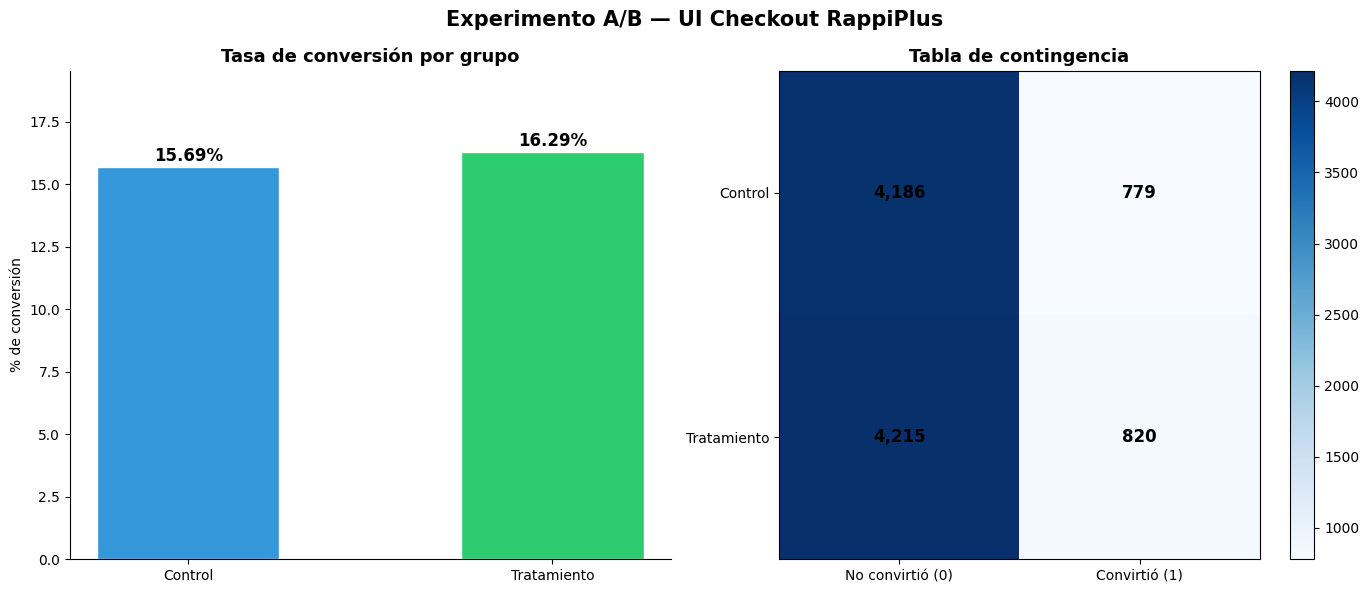

Gráfico guardado como test_estadistico_ab.png


In [36]:
# VISUALIZACIÓN

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Experimento A/B — UI Checkout RappiPlus', fontsize=15, fontweight='bold')

# GRÁFICO 1: TASAS DE CONVERSIÓN 
ax1 = axes[0]
grupos  = ['Control', 'Tratamiento']
tasas   = [tasa_control, tasa_tratamiento]
colores = ['#3498db', '#2ecc71']

bars = ax1.bar(grupos, tasas, color=colores, edgecolor='white', width=0.5)
for bar, tasa in zip(bars, tasas):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{tasa:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)

ax1.set_title('Tasa de conversión por grupo', fontsize=13, fontweight='bold')
ax1.set_ylabel('% de conversión')
ax1.set_ylim(0, max(tasas) * 1.2)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

#  GRÁFICO 2: TABLA DE CONTINGENCIA 
ax2 = axes[1]
tabla_plot = tabla.values
im = ax2.imshow(tabla_plot, cmap='Blues', aspect='auto')
plt.colorbar(im, ax=ax2)

ax2.set_xticks([0, 1])
ax2.set_xticklabels(['No convirtió (0)', 'Convirtió (1)'])
ax2.set_yticks([0, 1])
ax2.set_yticklabels(['Control', 'Tratamiento'])
ax2.set_title('Tabla de contingencia', fontsize=13, fontweight='bold')

for i in range(2):
    for j in range(2):
        ax2.text(j, i, f'{tabla_plot[i, j]:,}',
                 ha='center', va='center', fontweight='bold', fontsize=12, color='black')

plt.tight_layout()
plt.savefig('test_estadistico_ab.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado como test_estadistico_ab.png")

**Test Estadístico — Experimento A/B Checkout UI**

**Contexto**

Se evaluó si el cambio en la UI del checkout tuvo impacto en la tasa de conversión de compra. El experimento contó con **10,000 usuarios** divididos en dos grupos:

| Grupo | Usuarios |
|---|---|
| Control | 4,965 |
| Tratamiento | 5,035 |

---

**📋 Hipótesis estadística

- **H₀ (Hipótesis nula):** La tasa de conversión de control = tratamiento. El cambio en la UI no tiene impacto.
- **H₁ (Hipótesis alternativa):** La tasa de conversión de control ≠ tratamiento. El cambio en la UI sí tiene impacto.
- **Test aplicado:** Chi-cuadrado de independencia
- **Nivel de significancia (alpha):** 0.05

> Se eligió el test **Chi-cuadrado** porque la variable dependiente `convirtio` es binaria (0 = no compró, 1 = sí compró) y la variable independiente `variante` es categórica (control / tratamiento).

---

**Tasas de conversión**

| Grupo | Tasa de conversión |
|---|---|
| Control | 15.69% |
| Tratamiento | 16.29% |
| **Diferencia** | **+0.60%** |

---

**Resultado del test**

| Métrica | Valor |
|---|---|
| Chi² | 0.6178 |
| P-value | 0.4319 |
| Grados de libertad | 1 |
| Alpha | 0.05 |

---

**Interpretación**

El **p-value de 0.4319 es mayor que alpha (0.05)**, por lo tanto **no se rechaza H₀**.

Aunque numéricamente el grupo tratamiento tuvo una conversión ligeramente mayor (16.29% vs 15.69%), la diferencia de **+0.60%** no es estadísticamente significativa. Es decir, podría deberse simplemente al **azar** y no al cambio en la UI del checkout.

---

**Respuesta para el negocio**

> **Resultado:** El cambio en la UI del checkout **no generó un impacto estadísticamente significativo** en la tasa de conversión.
>
> **Números:** El grupo con la nueva UI convirtió un 16.29% vs 15.69% del grupo control, una diferencia de apenas +0.60% que el test estadístico indica que puede ser producto del azar (p-value = 0.43).

---

**Recomendaciones accionables**

- **Analizar por segmento:** Revisar si el cambio tuvo impacto en grupos específicos por dispositivo o país, ya que el efecto podría estar concentrado en un segmento particular.
- **Rediseñar la variante:** Desarrollar una nueva versión con cambios más profundos en el formulario de pago, enfocándose en reducir fricción.
- **Extender el experimento:** Correr el test con más usuarios o más tiempo para detectar diferencias más pequeñas con mayor precisión estadística.

---

## 🔹 Paso 6: Comunicar los resultados (Dashboard en BI)

🎯 **Objetivo**:  
Crear un dashboard que muestre de manera clara y visual los resultados del análisis de ventas, costos, marketing y conversión. 

Se usarán los CSVs limpios del Paso 1:

- `orders_clean.csv`  
- `catalog_clean.csv`  
- `marketing_clean.csv`

---

1️⃣ Preparación de los datos
1. Cargar los CSVs en Power BI o Tableau.
2. Revisar relaciones:
   - `orders.nombre_producto` → `catalog.nombre_producto`
   - `orders.fecha_pedido` → tabla de fechas (crear calendario para análisis temporal)
   - `orders.fecha_pedido` → `dim_fecha.date`
3. Crear columnas calculadas necesarias
4. Crear tabla de fechas para poder calcular comparaciones YTD, YoY o períodos anteriores (`Previous Year`, `Previous Month`).

---

2️⃣ Dashboard 1: Overview Ejecutivo
**KPIs principales a mostrar:**
- Revenue total
- Profit total
- Gasto total en marketing
- Ticket promedio
- Cantidad promedio de productos por orden

**Visualizaciones sugeridas:**
- Tarjetas KPI para revenue, profit y gasto marketing
- Gráfico de líneas: evolución mensual de revenue o profit
- Gráfico de líneas YTD
- Gráfico de barras: revenue y profit por producto o categoría

---

 3️⃣ Dashboard 2: Detalle / Drill-through  
**Objetivo:** Permitir explorar los datos desde el KPI general hasta cada orden o producto.

**Visualizaciones sugeridas:**
- Tabla detallada de órdenes con:
  - producto, cantidad, revenue, cost, profit
  - color condicional (profit negativo en rojo, positivo en verde)
- Gráfico de barras por producto con medida `cantidad vendida`
- Drill-through: seleccionar un producto y ver todos los pedidos relacionados
- Filtros por fecha, categoría de producto, etc

---

## 🚀 Entrega Final

Comparte el acceso a tu Dashboard para revisión.   
Puedes entregar el Dashboard utilizando **Power BI o Tableau**.

Incluye **uno de los siguientes**:

- 🔗 Link público del dashboard publicado en **Power BI Service o Tableau Public / Tableau Cloud**
- 🔗 Link de **Google Drive o OneDrive** con el archivo del proyecto (`.pbix`) y los 3 csvs limpios.


### 📎 Enlace del Dashboard

In [ ]:
# https://drive.google.com/drive/folders/1psBm2cLC9TuPNJmjRdjmlgz-PYjWUliw?usp=sharing

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Buen cierre del flujo: la guía del dashboard en BI cubre KPIs, relaciones entre tablas y drill-through; el enlace a material del .pbix permite revisar la entrega fuera del notebook.

Agregas la pestaña con tarjetas de ventas, gasto, profit neto y ticket promedio y gráficas complementarias por tipo de producto y series de tiempo. Esto en la segundo pestaña lo complementas con un análisis por producto y filtros del trimestre.
</div>